In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_google_genai import ChatGoogleGenerativeAI
import google.auth

# List available models via the REST API directly
import requests
api_key = os.environ.get("GEMINI_API_KEY")
resp = requests.get(
    f"https://generativelanguage.googleapis.com/v1beta/models?key={api_key}"
)
for m in resp.json().get("models", []):
    if "generateContent" in m.get("supportedGenerationMethods", []):
        print(m["name"])

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [2]:
import subprocess
subprocess.run(["pip", "install", "langchain>=0.3.0"], check=True)

CompletedProcess(args=['pip', 'install', 'langchain>=0.3.0'], returncode=0)

# Avis — Agentic AI Birdfeeder Demo
## CS 450 Introduction to AI — SDSU Spring 2026
### Kane Cruz-Walker · Daniel Wen

This notebook demonstrates both agent architectures running side by side:
- **BirdAnalystAgent** — custom in-house tool-calling agent (Gemini API, no framework)
- **LangChainAnalyst** — LangGraph-based conversational agent with three memory layers

Both agents call the same underlying tool functions from `src/agent/tools/`.

**Toggle between synthetic and real Pi data:**
```python
USE_SYNTHETIC = True   # offline demo — works without Pi
USE_SYNTHETIC = False  # uses real logs/observations.jsonl from Pi
```


In [3]:
import sys, json, os
from pathlib import Path
from datetime import UTC, datetime, timedelta
import warnings

# Load .env so GEMINI_API_KEY is available in the notebook kernel
from dotenv import load_dotenv
load_dotenv(Path(".").resolve().parent / ".env")
print(f"Gemini key loaded: {bool(os.environ.get('GEMINI_API_KEY'))}")


warnings.filterwarnings("ignore")

# Make src/ importable
sys.path.insert(0, str(Path(".").resolve().parent))

# ── Demo toggle ───────────────────────────────────────────────────────────────
USE_SYNTHETIC = True   # set False to use real Pi data

SYNTHETIC_OBS_PATH  = Path("demo_data/observations.jsonl")
REAL_OBS_PATH       = Path("../logs/observations.jsonl")
THRESHOLDS_PATH     = Path("../configs/thresholds.yaml")
DECISIONS_LOG_PATH  = Path("demo_data/analyst_decisions.jsonl")
DAILY_SUMMARIES_DIR = Path("demo_data/daily_summaries")

OBS_PATH = SYNTHETIC_OBS_PATH if USE_SYNTHETIC else REAL_OBS_PATH
print(f"Data source: {'synthetic' if USE_SYNTHETIC else 'real Pi data'}")
print(f"Observations: {OBS_PATH}")


Gemini key loaded: True
Data source: synthetic
Observations: demo_data\observations.jsonl


## 1. Generate Synthetic Data

Creates realistic birdfeeder observations across 7 days for offline demo.
Skip this cell if using real Pi data.

In [4]:
if USE_SYNTHETIC:
    import random, yaml
    random.seed(42)
    
    SYNTHETIC_OBS_PATH.parent.mkdir(exist_ok=True)
    DAILY_SUMMARIES_DIR.mkdir(exist_ok=True)
    
    # Realistic SD feeder species with typical confidence ranges
    SPECIES = [
        ("HOFI", "House Finch",        0.82, 0.94),
        ("MODO", "Mourning Dove",       0.78, 0.91),
        ("BLPH", "Black Phoebe",        0.85, 0.97),
        ("HOSP", "House Sparrow",       0.72, 0.88),
        ("WCSP", "White-crowned Sparrow",0.75, 0.90),
        ("ANHU", "Anna's Hummingbird",  0.80, 0.95),
        ("LEGO", "Lesser Goldfinch",    0.76, 0.89),
        ("WBNU", "White-breasted Nuthatch",0.83,0.96),
    ]
    
    def rand_conf(lo, hi): return round(random.uniform(lo, hi), 3)
    
    obs_list = []
    now = datetime.now(UTC)
    
    # 7 days of data with realistic activity patterns
    # Day 1-4: healthy feeder (8-12 detections/day)
    # Day 5-6: declining feeder (5-7 detections/day)  
    # Day 7: low food (2-3 detections/day)
    daily_counts = [10, 12, 9, 11, 6, 5, 3]
    
    for day_offset, n_detections in enumerate(daily_counts):
        base_day = now - timedelta(days=6 - day_offset)
        
        for _ in range(n_detections):
            # Dawn/dusk activity peak
            hour = random.choices(
                [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
                weights=[3, 4, 4, 3, 2, 1, 1, 1, 2, 3, 3, 4, 3],
            )[0]
            ts = base_day.replace(hour=hour, minute=random.randint(0,59),
                                  second=random.randint(0,59))
            
            code_, name, lo, hi = random.choices(
                SPECIES,
                weights=[4, 3, 2, 3, 2, 1, 1, 1],  # HOFI most common
            )[0]
            
            mode = random.choices(["fixed_crop","yolo"], weights=[6, 4])[0]
            a_conf = rand_conf(lo, hi)
            v_conf = rand_conf(lo, hi)
            # YOLO slightly higher confidence (Hailo benefit)
            if mode == "yolo":
                v_conf = min(0.99, v_conf + 0.03)
            
            fused = round(0.55 * a_conf + 0.45 * v_conf, 3)
            
            obs_list.append({
                "species_code": code_,
                "common_name": name,
                "scientific_name": "Synthetic species",
                "fused_confidence": fused,
                "detection_mode": mode,
                "timestamp": ts.isoformat(),
                "audio_result": {"species_code": code_, "confidence": a_conf,
                                 "modality": "audio"},
                "visual_result": {"species_code": code_, "confidence": v_conf,
                                  "modality": "visual"},
            })
    
    # Sort chronologically
    obs_list.sort(key=lambda x: x["timestamp"])
    
    with SYNTHETIC_OBS_PATH.open("w") as f:
        for o in obs_list:
            f.write(json.dumps(o) + "\n")
    
    print(f"Generated {len(obs_list)} synthetic observations across 7 days")
    print(f"Species: {[s[0] for s in SPECIES]}")
    print(f"Activity pattern: {daily_counts} detections per day")
    print(f"Note: Days 5-7 show declining activity (feeder going low)")
else:
    print("Using real Pi data — skipping synthetic generation")


Generated 56 synthetic observations across 7 days
Species: ['HOFI', 'MODO', 'BLPH', 'HOSP', 'WCSP', 'ANHU', 'LEGO', 'WBNU']
Activity pattern: [10, 12, 9, 11, 6, 5, 3] detections per day
Note: Days 5-7 show declining activity (feeder going low)


## 2. Visualise the Data

Quick overview before running the agents.

Total observations: 56
Unique species: 8
Date range: 2026-04-11 → 2026-04-17
Mean confidence: 0.866


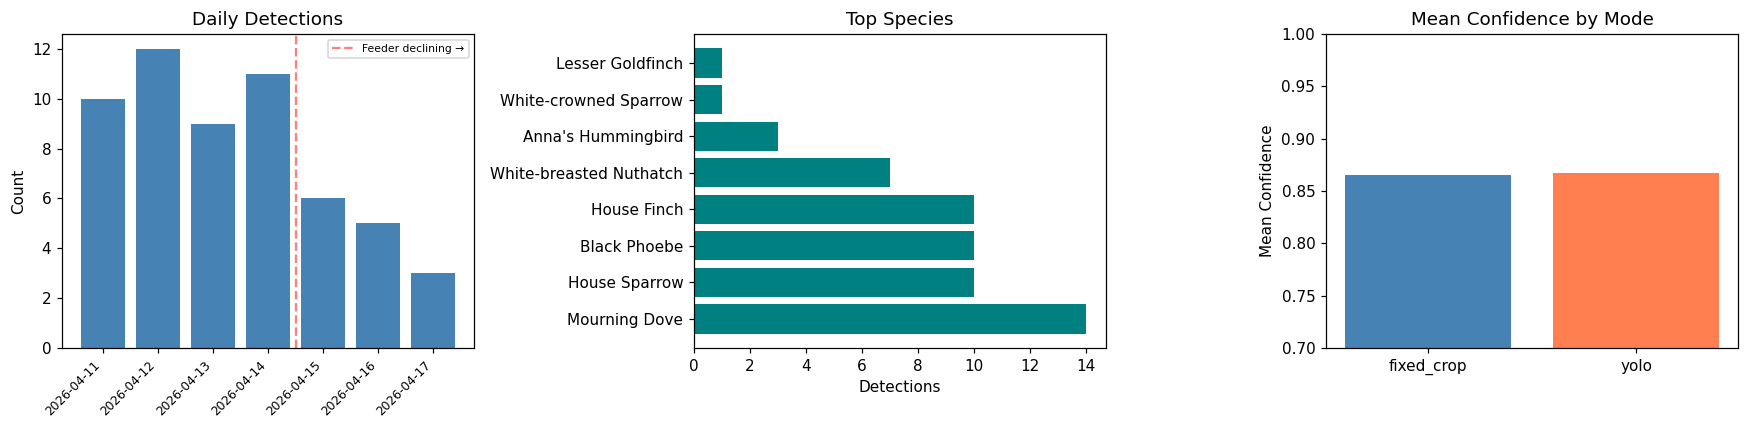

Overview chart saved.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110

# Load observations
obs_records = []
with open(OBS_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                obs_records.append(json.loads(line))
            except:
                pass

df = pd.DataFrame(obs_records)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour

print(f"Total observations: {len(df)}")
print(f"Unique species: {df['species_code'].nunique()}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"Mean confidence: {df['fused_confidence'].mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Daily detections
daily = df.groupby("date").size()
axes[0].bar(range(len(daily)), daily.values, color="steelblue")
axes[0].set_xticks(range(len(daily)))
axes[0].set_xticklabels([str(d) for d in daily.index], rotation=45, ha="right", fontsize=8)
axes[0].set_title("Daily Detections")
axes[0].set_ylabel("Count")
if USE_SYNTHETIC:
    axes[0].axvline(3.5, color="red", linestyle="--", alpha=0.5, label="Feeder declining →")
    axes[0].legend(fontsize=7)

# Species breakdown
species_counts = df["common_name"].value_counts().head(8)
axes[1].barh(species_counts.index, species_counts.values, color="teal")
axes[1].set_title("Top Species")
axes[1].set_xlabel("Detections")

# Detection mode comparison
mode_conf = df.groupby("detection_mode")["fused_confidence"].mean()
colors = ["steelblue" if m == "fixed_crop" else "coral" for m in mode_conf.index]
axes[2].bar(mode_conf.index, mode_conf.values, color=colors)
axes[2].set_title("Mean Confidence by Mode")
axes[2].set_ylabel("Mean Confidence")
axes[2].set_ylim(0.7, 1.0)

plt.tight_layout()
plt.savefig("demo_data/overview.png", bbox_inches="tight")
plt.show()
print("Overview chart saved.")


## 3. Custom Agent (BirdAnalystAgent)

Our in-house tool-calling agent. No framework — we wrote the loop.
Shows autonomous decision-making: reads data, reasons, calls tools.

In [6]:
from src.agent.bird_analyst_agent import BirdAnalystAgent

custom_agent = BirdAnalystAgent(
    observations_path=str(OBS_PATH),
    decisions_log_path=str(DECISIONS_LOG_PATH),
    daily_summaries_dir=str(DAILY_SUMMARIES_DIR),
    provider="gemini",
    model="gemini-2.5-flash",
    enabled=True,
)

print(f"BirdAnalystAgent ready | LLM available: {custom_agent.llm_available}")
print(f"Tools registered: {len(list(__import__('src.agent.tools', fromlist=['TOOL_REGISTRY']).TOOL_REGISTRY.keys()))}")


BirdAnalystAgent ready | LLM available: True
Tools registered: 11


In [7]:
# Demonstrate advise() — the autonomous decision path
# This is what ExperimentOrchestrator calls every 30 minutes

print("=" * 55)
print("BirdAnalystAgent.advise() — Autonomous Decision Cycle")
print("=" * 55)

decision = custom_agent.advise(
    current_mode="fixed_crop",
    uptime_seconds=3600.0,
    window_elapsed_minutes=28.0,
    window_total_minutes=30.0,
)

if decision:
    print(f"\nLLM Available: {decision.llm_available}")
    print(f"Switch mode:   {decision.switch_mode or 'no switch'}")
    print(f"Generate report: {decision.generate_report}")
    print(f"Push message:  {decision.push_message or 'none'}")
    print(f"Tools called:  {decision.tools_called}")
    print(f"\nReasoning:")
    print(decision.reasoning[:500] if decision.reasoning else "(no reasoning)")
else:
    print("LLM unavailable — orchestrator would fall back to fixed schedule")
    print("(Set GEMINI_API_KEY in .env to enable live LLM reasoning)")


BirdAnalystAgent.advise() — Autonomous Decision Cycle

LLM Available: True
Switch mode:   no switch
Generate report: False
Push message:  [pushed by agent]
Tools called:  ['read_recent_observations', 'get_detection_stats', 'get_feeder_health', 'push_notification', 'log_analyst_decision']

Reasoning:
[{'type': 'text', 'text': 'I have assessed the current situation. There have been no bird detections in the last hour since the system started, and thus insufficient data to compare detection modes. However, the feeder health is reported as "declining" based on historical data, with a 50% drop in detection count over the last 3 days. I attempted to send a push notification to the owner about this, but it failed. I have logged this decision.', 'extras': {'signature': 'CrUFAQw51sdJSu7NSq/avZdadgeyP0Hi806UH9YmJEaV1WRzTqa4bqRLIGD9DB6HKoKeyohCMoyZvGBjLcN7yTtf5Qx8I5Aa6ylwRVRtTKbXLXNvx9O7yIT0bvKlUriW5UzJLqC2KOnfWhOI3m2P3uAaItGYZP4/TafPSRQNJhbSivA5Al9wk66X+br2K+94ZdSpWQENwrImsMiovtqj2z5cVCyrLjAf7l2

In [8]:
import time
print("Waiting 60s for rate limit reset...")
time.sleep(60)

Waiting 60s for rate limit reset...


In [9]:
# Demonstrate answer() — reactive query path
print("=" * 55)
print("BirdAnalystAgent.answer() — Reactive Query")
print("=" * 55)

resp = custom_agent.answer("What birds have been most active today?")

print(f"\nAnswer: {resp.answer}")
print(f"Tools called: {resp.tools_called}")
print(f"Confidence: {resp.confidence}")
print(f"LLM available: {resp.llm_available}")


BirdAnalystAgent.answer() — Reactive Query

Answer: [{'type': 'text', 'text': 'Today, the most active bird has been the House Finch (HOFI) with 2 detections, followed by the House Sparrow (HOSP) with 1 detection.', 'extras': {'signature': 'CvwCAQw51scPRKJRX5PO16WDoF53hhS2QcvMTtHkSiGE2zz9U0HMh1ARJhL8hs9XBMp9FO2iqIJ89SaqwofWgM1OOwE6TZDWtdNbAh1hXO3wSlzLG4Mc8QkENZIVONQK02gtVl8ZkuF/4OkwhgZGMcqtR8WZbY2+zzE4Jag2LRR2Y2UWBrpWIcF+cRhA2kdFxUSB2YMOPLwSIWUnPdUNcWDbnLHupTWMM26yuBMsWaOoBhySi5c0ieUxfLx5G4h/TFuckuro2BYMRGdmSgSPYOiXUnyNcu04P698SFpImSig2RF5gFvBNe9A+F1/xEOQLGeDxxcWKxhVBuEq8/Jr4Q+SqSscrH9F4ALKeGthpSA5iWw7295XTBLs0W50PU4PYkCF7WAv2H9wA/Bn2LOCMshawzyF8Kwn1bhae49p+1K4bemkMD/gl1g+Vg1Z8OwItTn+xpcM+5kj+xyivulw0/Uf4IBuD2mHZOpGUXC1zbk0ARvn2HRawWLHHeca7Zw='}}]
Tools called: ['get_top_species']
Confidence: high
LLM available: True


## 4. LangGraph Agent (LangChainAnalyst)

Framework-based conversational agent with three memory layers.
Uses LangGraph's explicit state machine — the architecture the professor asked for.

In [10]:
from src.agent.langchain_analyst import LangChainAnalyst

lc_analyst = LangChainAnalyst(
    observations_path=str(OBS_PATH),
    thresholds_path=str(THRESHOLDS_PATH) if THRESHOLDS_PATH.exists() else "configs/thresholds.yaml",
    decisions_log_path=str(DECISIONS_LOG_PATH),
    daily_summaries_dir=str(DAILY_SUMMARIES_DIR),
    provider="gemini",
    model="gemini-2.5-flash",
    enabled=True,
)

print(f"LangChainAnalyst ready | Available: {lc_analyst.available}")


LangChainAnalyst ready | Available: True


In [11]:
# Show the LangGraph agent graph diagram
# This is the perceive → reason → act → memory state machine
print("LangGraph Agent Architecture:")
print("=" * 55)
diagram = lc_analyst.get_graph_diagram()
print(diagram)

# In a Jupyter environment with IPython display:
try:
    from IPython.display import display, Markdown
    display(Markdown(f"```mermaid\n{diagram}\n```"))
except Exception:
    print("(diagram above is Mermaid format — renders in GitHub or Mermaid Live)")


LangGraph Agent Architecture:
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

In [12]:
# Multi-turn demo — watch memory build across questions
print("=" * 55)
print("LangChainAnalyst — Multi-turn Memory Demo")
print("=" * 55)

questions = [
    "What are the most common birds at the feeder?",
    "Which of those had the highest confidence scores?",
    "Is that typical for them, or is it unusually high?",
    "How is the feeder doing — does it need refilling?",
]

for i, q in enumerate(questions, 1):
    print(f"\nTurn {i}: {q}")
    print("-" * 40)
    
    resp = lc_analyst.answer(q)
    
    print(f"Answer: {resp.answer[:300]}{'...' if len(resp.answer) > 300 else ''}")
    print(f"Tools: {resp.tools_called}")
    
    # Show memory state after each turn
    mem = lc_analyst.get_memory_summary()
    print(f"Memory: {mem['layer1_conversation_turns']} turns | "
          f"Entities: {mem['layer2_entities']} | "
          f"Cache: {mem['layer3_tool_cache_keys']}")


LangChainAnalyst — Multi-turn Memory Demo

Turn 1: What are the most common birds at the feeder?
----------------------------------------
Answer: The most common birds at the feeder are House Finches (2 detections) and House Sparrows (1 detection) in the last 24 hours.
Tools: ['get_top_species', 'log_analyst_decision']
Memory: 1 turns | Entities: {'asked_about_feeder_health': True} | Cache: ['get_top_species']

Turn 2: Which of those had the highest confidence scores?
----------------------------------------
Answer: Which of those had the highest confidence scores?

[Session cache — already fetched this session: get_top_species. Reuse cached data where appropriate.]
Tools: []
Memory: 2 turns | Entities: {'asked_about_feeder_health': True} | Cache: ['get_top_species']

Turn 3: Is that typical for them, or is it unusually high?
----------------------------------------
Answer: {"success": true, "logged_at": "2026-04-17T22:41:23.196637+00:00"}
Tools: ['query_species_history', 'query_specie

## 5. Calibration Tools Demo

The agent can tune its own classification pipeline from live data.

In [13]:
from src.agent.tools.calibration_tools import (
    run_fusion_weight_sweep,
    evaluate_detection_threshold,
    compare_model_backends,
    apply_fusion_weights,
)

print("=" * 55)
print("Calibration Tool: Fusion Weight Sweep")
print("=" * 55)

sweep = run_fusion_weight_sweep(str(OBS_PATH), hours=168.0)  # full 7 days

print(f"Observations analysed: {sweep['n_observations']}")
print(f"Dual-modality samples: {sweep['n_with_both_modalities']}")
print(f"\nCurrent weights: audio={sweep['current_weights']['audio']}, "
      f"visual={sweep['current_weights']['visual']}")

if sweep["recommended"]:
    rec = sweep["recommended"]
    print(f"Recommended:     audio={rec['audio_weight']}, visual={rec['visual_weight']}")
    print(f"Improvement:     {rec['improvement_over_current']:+.4f} mean confidence")

print(f"\nReasoning: {sweep['reasoning']}")


Calibration Tool: Fusion Weight Sweep
Observations analysed: 56
Dual-modality samples: 56

Current weights: audio=0.55, visual=0.44999999999999996
Recommended:     audio=0.17, visual=0.83
Improvement:     +0.0037 mean confidence

Reasoning: Sweep across 5 weight combinations on 56 dual-modality observations. Best weights (audio=0.17, visual=0.83) give only +0.004 mean confidence vs current. Difference is negligible — recommend keeping current weights.


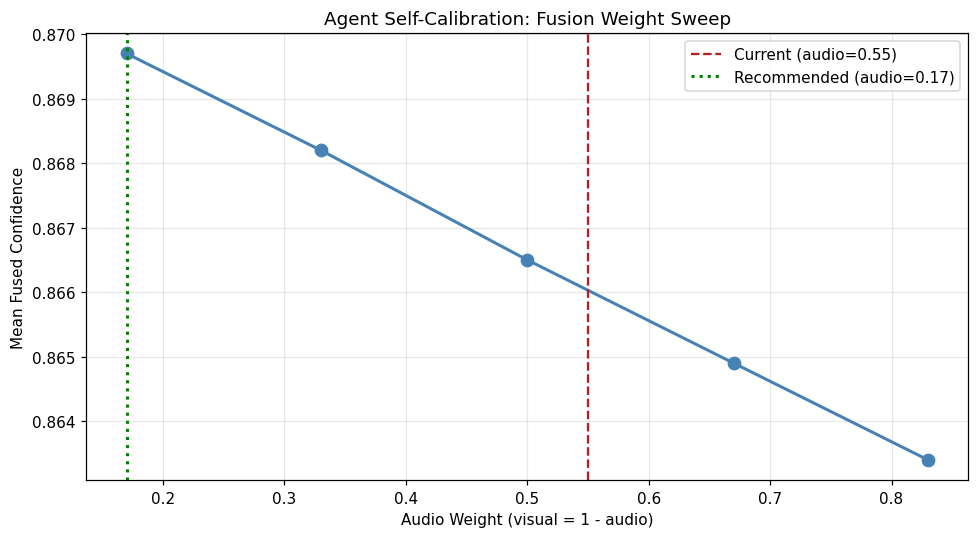

Fusion sweep chart saved.


In [14]:
# Plot the sweep results
if sweep["sweep_results"]:
    fig, ax = plt.subplots(figsize=(9, 5))
    
    audio_weights = [r["audio_weight"] for r in sweep["sweep_results"]]
    mean_confs = [r["mean_fused_confidence"] for r in sweep["sweep_results"]]
    
    # Sort by audio weight for clean plot
    paired = sorted(zip(audio_weights, mean_confs))
    aw, mc = zip(*paired)
    
    ax.plot(aw, mc, "o-", color="steelblue", linewidth=2, markersize=8)
    ax.axvline(0.55, color="firebrick", linestyle="--",
               label="Current (audio=0.55)")
    
    if sweep["recommended"]:
        ax.axvline(sweep["recommended"]["audio_weight"], color="green",
                   linestyle=":", linewidth=2,
                   label=f"Recommended (audio={sweep['recommended']['audio_weight']})")
    
    ax.set_xlabel("Audio Weight (visual = 1 - audio)")
    ax.set_ylabel("Mean Fused Confidence")
    ax.set_title("Agent Self-Calibration: Fusion Weight Sweep")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("demo_data/fusion_sweep.png", bbox_inches="tight")
    plt.show()
    print("Fusion sweep chart saved.")


In [15]:
print("=" * 55)
print("Calibration Tool: Detection Threshold Sweep")
print("=" * 55)

thresh_result = evaluate_detection_threshold(str(OBS_PATH), hours=168.0, steps=6)
print(f"Current threshold: {thresh_result['current_threshold']}")
print(f"Recommended:       {thresh_result['recommended_threshold']}")
print(f"\nSweep results:")
for r in thresh_result["sweep_results"]:
    marker = " ← current" if abs(r["threshold"] - 0.70) < 0.01 else ""
    marker += " ← recommended" if abs(r["threshold"] - thresh_result["recommended_threshold"]) < 0.01 and marker == "" else ""
    print(f"  threshold={r['threshold']:.2f}: "
          f"{r['detections_passed']} passed ({r['pass_rate_pct']:.0f}%), "
          f"mean_conf={r['mean_confidence_passed']:.3f}{marker}")

print(f"\nReasoning: {thresh_result['reasoning']}")


Calibration Tool: Detection Threshold Sweep
Current threshold: 0.7
Recommended:       0.6

Sweep results:
  threshold=0.60: 56 passed (100%), mean_conf=0.866 ← recommended
  threshold=0.65: 56 passed (100%), mean_conf=0.866
  threshold=0.70: 56 passed (100%), mean_conf=0.866 ← current
  threshold=0.75: 56 passed (100%), mean_conf=0.866
  threshold=0.80: 50 passed (89%), mean_conf=0.877
  threshold=0.85: 40 passed (71%), mean_conf=0.893

Reasoning: Swept 6 thresholds on 56 observations. Current threshold 0.7 passes 100% of detections. Recommended threshold 0.6 balances coverage and precision.


In [16]:
print("=" * 55)
print("Calibration Tool: Backend Comparison (Hailo vs CPU)")
print("=" * 55)

backend = compare_model_backends(str(OBS_PATH), hours=168.0)
print(f"Recommendation: {backend['recommendation']}")
print(f"Hailo delta:    {backend['hailo_delta']:+.4f}")
print()
for mode, stats in backend["by_detection_mode"].items():
    print(f"  {mode:12s}: n={stats['n']:3d} "
          f"mean_conf={stats['mean_conf']:.3f} "
          f"std={stats['std_conf']:.3f}")
print(f"\nReasoning: {backend['reasoning']}")


Calibration Tool: Backend Comparison (Hailo vs CPU)
Recommendation: no_preference
Hailo delta:    +0.0021

  fixed_crop  : n= 27 mean_conf=0.865 std=0.049
  yolo        : n= 29 mean_conf=0.867 std=0.050

Reasoning: Both modes performing similarly (delta=+0.002). A/B switching is not degrading quality. Continue experiment.


## 6. Memory Visualisation

Shows all three memory layers building in real time.

In [17]:
# Show memory state after the multi-turn demo above
print("=" * 55)
print("LangChainAnalyst Memory State")
print("=" * 55)

mem_state = lc_analyst.get_memory_summary()

print(f"\nLayer 1 — Conversation Buffer")
print(f"  Turns in memory: {mem_state['layer1_conversation_turns']}")
for msg in mem_state["layer1_messages"]:
    print(f"  [{msg['role']:9s}] {msg['preview'][:70]}...")

print(f"\nLayer 2 — Entity Store")
for key, value in mem_state["layer2_entities"].items():
    print(f"  {key}: {value}")

print(f"\nLayer 3 — Session Tool Cache")
for key in mem_state["layer3_tool_cache_keys"]:
    print(f"  {key} (cached this session)")

print(f"\nEffect of memory:")
print(f"  Without Layer 1: every question is answered without conversation context")
print(f"  Without Layer 2: 'which of those?' requires agent to re-ask which species")
print(f"  Without Layer 3: every follow-up re-queries the observations log")


LangChainAnalyst Memory State

Layer 1 — Conversation Buffer
  Turns in memory: 4
  [user     ] Which of those had the highest confidence scores?...
  [assistant] Which of those had the highest confidence scores?

[Session cache — al...
  [user     ] Is that typical for them, or is it unusually high?...
  [assistant] {"success": true, "logged_at": "2026-04-17T22:41:23.196637+00:00"}...
  [user     ] How is the feeder doing — does it need refilling?...
  [assistant] The feeder's health is declining. The detection count has dropped by 5...

Layer 2 — Entity Store
  asked_about_feeder_health: True

Layer 3 — Session Tool Cache
  get_top_species (cached this session)
  get_feeder_health (cached this session)

Effect of memory:
  Without Layer 1: every question is answered without conversation context
  Without Layer 2: 'which of those?' requires agent to re-ask which species
  Without Layer 3: every follow-up re-queries the observations log


## 7. Analyst Decision Log

Every agent reasoning cycle is logged to `analyst_decisions.jsonl`.
This is the audit trail the professor can inspect.

In [18]:
decisions_path = DECISIONS_LOG_PATH

if decisions_path.exists():
    decisions = []
    with decisions_path.open() as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    decisions.append(json.loads(line))
                except:
                    pass
    
    print(f"Total decisions logged: {len(decisions)}")
    print()
    
    for i, d in enumerate(decisions[-3:], 1):  # show last 3
        print(f"Decision {i}:")
        print(f"  Timestamp:    {d.get('timestamp', 'N/A')}")
        print(f"  Mode:         {d.get('mode', 'N/A')}")
        print(f"  Observations: {d.get('observations_summary', 'N/A')}")
        print(f"  Actions:      {d.get('actions_taken', [])}")
        print(f"  Reasoning:    {d.get('reasoning', 'N/A')[:200]}...")
        print()
else:
    print("No decisions logged yet.")
    print("Decisions are written when the agent runs with a live GEMINI_API_KEY.")
    print("Each entry records: timestamp, mode, observations summary, actions, reasoning.")


Total decisions logged: 5

Decision 1:
  Timestamp:    2026-04-17T22:41:14.372147+00:00
  Mode:         fixed_crop
  Observations: {"get_top_species_response": {"species": [{"code": "HOFI", "count": 2, "mean_confidence": 0.883, "name": "House Finch", "rank": 1}, {"code": "HOSP", "count": 1, "mean_confidence": 0.767, "name": "House Sparrow", "rank": 2}], "total_detections": 3, "window_hours": 24}}
  Actions:      ['get_top_species']
  Reasoning:    User asked for the most common birds at the feeder. Used get_top_species to retrieve the information....

Decision 2:
  Timestamp:    2026-04-17T22:41:23.196637+00:00
  Mode:         fixed_crop
  Observations: Current mean confidence for House Finches (0.92) is slightly higher than their 30-day average (0.889). Current mean confidence for House Sparrows (0.85) is slightly higher than their 30-day average (0.795).
  Actions:      ['query_species_history']
  Reasoning:    Compared current confidence scores for House Finches and House Sparrows w

## 8. Architecture Comparison

Side-by-side summary of both agents for the presentation.

In [19]:
print("=" * 65)
print("ARCHITECTURE COMPARISON")
print("=" * 65)
print()
print(f"{'Attribute':<28} {'BirdAnalystAgent':<20} {'LangChainAnalyst'}")
print("-" * 65)
rows = [
    ("Framework",         "Custom (in-house)",  "LangGraph"),
    ("LLM API",           "Gemini direct",      "LangChain-Gemini"),
    ("Primary path",      "advise() — proactive","answer() — reactive"),
    ("Trigger",           "Timer (30 min)",     "User query"),
    ("Memory Layer 1",    "—",                  "Conv. buffer (K=10)"),
    ("Memory Layer 2",    "—",                  "Entity store"),
    ("Memory Layer 3",    "—",                  "Session tool cache"),
    ("Tool source",       "src/agent/tools/",   "src/agent/tools/"),
    ("Tool interface",    "JSON schema (Gemini)","@tool decorator"),
    ("Decision log",      "analyst_decisions",  "analyst_decisions"),
    ("Calibration tools", "Yes",                "Yes"),
    ("Graceful fallback", "Returns None",       "Returns AnalystResponse"),
    ("Used for",          "Autonomous tuning",  "User queries + chat"),
]
for attr, custom, lc in rows:
    print(f"  {attr:<26} {custom:<20} {lc}")

print()
print("Both agents share the same tool functions from src/agent/tools/")
print("The tools are framework-agnostic — one implementation, two interfaces")


ARCHITECTURE COMPARISON

Attribute                    BirdAnalystAgent     LangChainAnalyst
-----------------------------------------------------------------
  Framework                  Custom (in-house)    LangGraph
  LLM API                    Gemini direct        LangChain-Gemini
  Primary path               advise() — proactive answer() — reactive
  Trigger                    Timer (30 min)       User query
  Memory Layer 1             —                    Conv. buffer (K=10)
  Memory Layer 2             —                    Entity store
  Memory Layer 3             —                    Session tool cache
  Tool source                src/agent/tools/     src/agent/tools/
  Tool interface             JSON schema (Gemini) @tool decorator
  Decision log               analyst_decisions    analyst_decisions
  Calibration tools          Yes                  Yes
  Graceful fallback          Returns None         Returns AnalystResponse
  Used for                   Autonomous tuning    Use